In [2]:
import numpy as np
import getdist as gd
import getdist.plots as gdplot
from getdist import loadMCSamples
import matplotlib.pyplot as plt


# Data

In [3]:
RUNS = [
    "lcdm_planck",
    "lcdm_planck_jwst",
    "lcdm_planck_desi_des",
    "lcdm_planck_desi_des_jwst",
]

samples = {
        run: loadMCSamples(f"../chains/{run}/{run}", settings={"ignore_rows": 0.0})
        for run in RUNS
}


for run, s in samples.items():
    print(run, "-> R-1:", s.getGelmanRubin(), "ESS:", s.getEffectiveSamples())

lcdm_planck -> R-1: 0.014139406956538793 ESS: 5741.694505317302
lcdm_planck_jwst -> R-1: 0.011033556504178794 ESS: 1651.2769824492746
lcdm_planck_desi_des -> R-1: 0.0182875070256154 ESS: 1072.678094482679
lcdm_planck_desi_des_jwst -> R-1: 0.05711157430315457 ESS: 641.3758772164283


## Triangle plots

In [4]:
## Remove burn-in
for run, s in samples.items():
    samples[run].removeBurn(0.3)

In [5]:
reio_params = s.getParamNames().list()[:6] + ["jwst_popIII_tau"]
cosmo_params = s.getParamNames().list()[6:12] + ["jwst_popIII_tau"]
print("reio params:", reio_params)
print("cosmo params:", cosmo_params)

reio params: ['reio_jwst_popIII_logMvcut', 'reio_jwst_popIII_fesc', 'reio_jwst_popIII_a', 'reio_jwst_popIII_b', 'reio_jwst_popIII_d', 'reio_jwst_popIII_zpop', 'jwst_popIII_tau']
cosmo params: ['H0', 'omega_b', 'omega_cdm', 'logA', 'n_s', 'A_planck', 'jwst_popIII_tau']


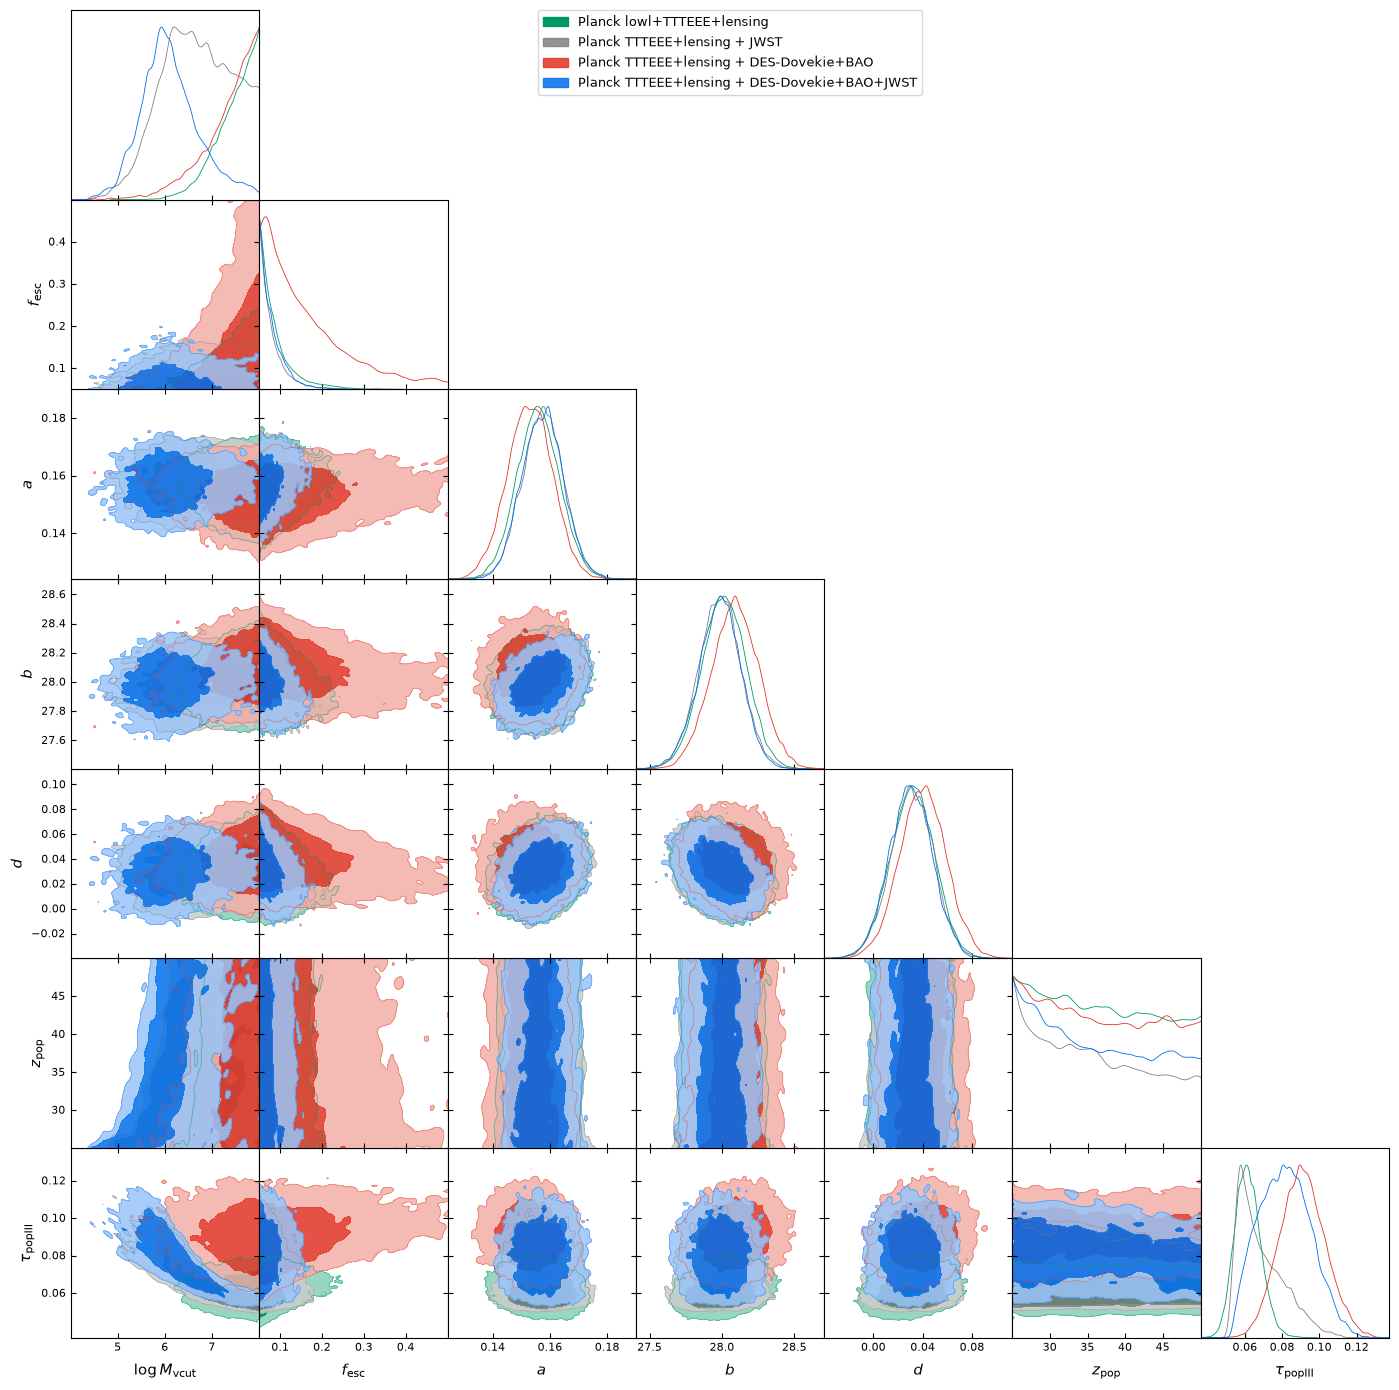

In [6]:
g = gdplot.get_subplot_plotter()

# Change smoothing
for s in samples.values():
    s.updateSettings({'smooth_scale_2D': 0.1, 'smooth_scale_1D': 0.1})

select_sims = slice(0, 4)
g.triangle_plot(
    [
        samples["lcdm_planck"],
        samples["lcdm_planck_jwst"],
        samples["lcdm_planck_desi_des"],
        samples["lcdm_planck_desi_des_jwst"]
    ][select_sims],
    # [samples["lcdm_planck_jwst"]],
    reio_params,
    # cosmo_params,
    filled=True,
    legend_labels=[
        "Planck lowl+TTTEEE+lensing",
        "Planck TTTEEE+lensing + JWST",
        "Planck TTTEEE+lensing + DES-Dovekie+BAO",
        "Planck TTTEEE+lensing + DES-Dovekie+BAO+JWST"
        ][select_sims],
    # title_limit=2 # 2 sigma range
)
plt.show()


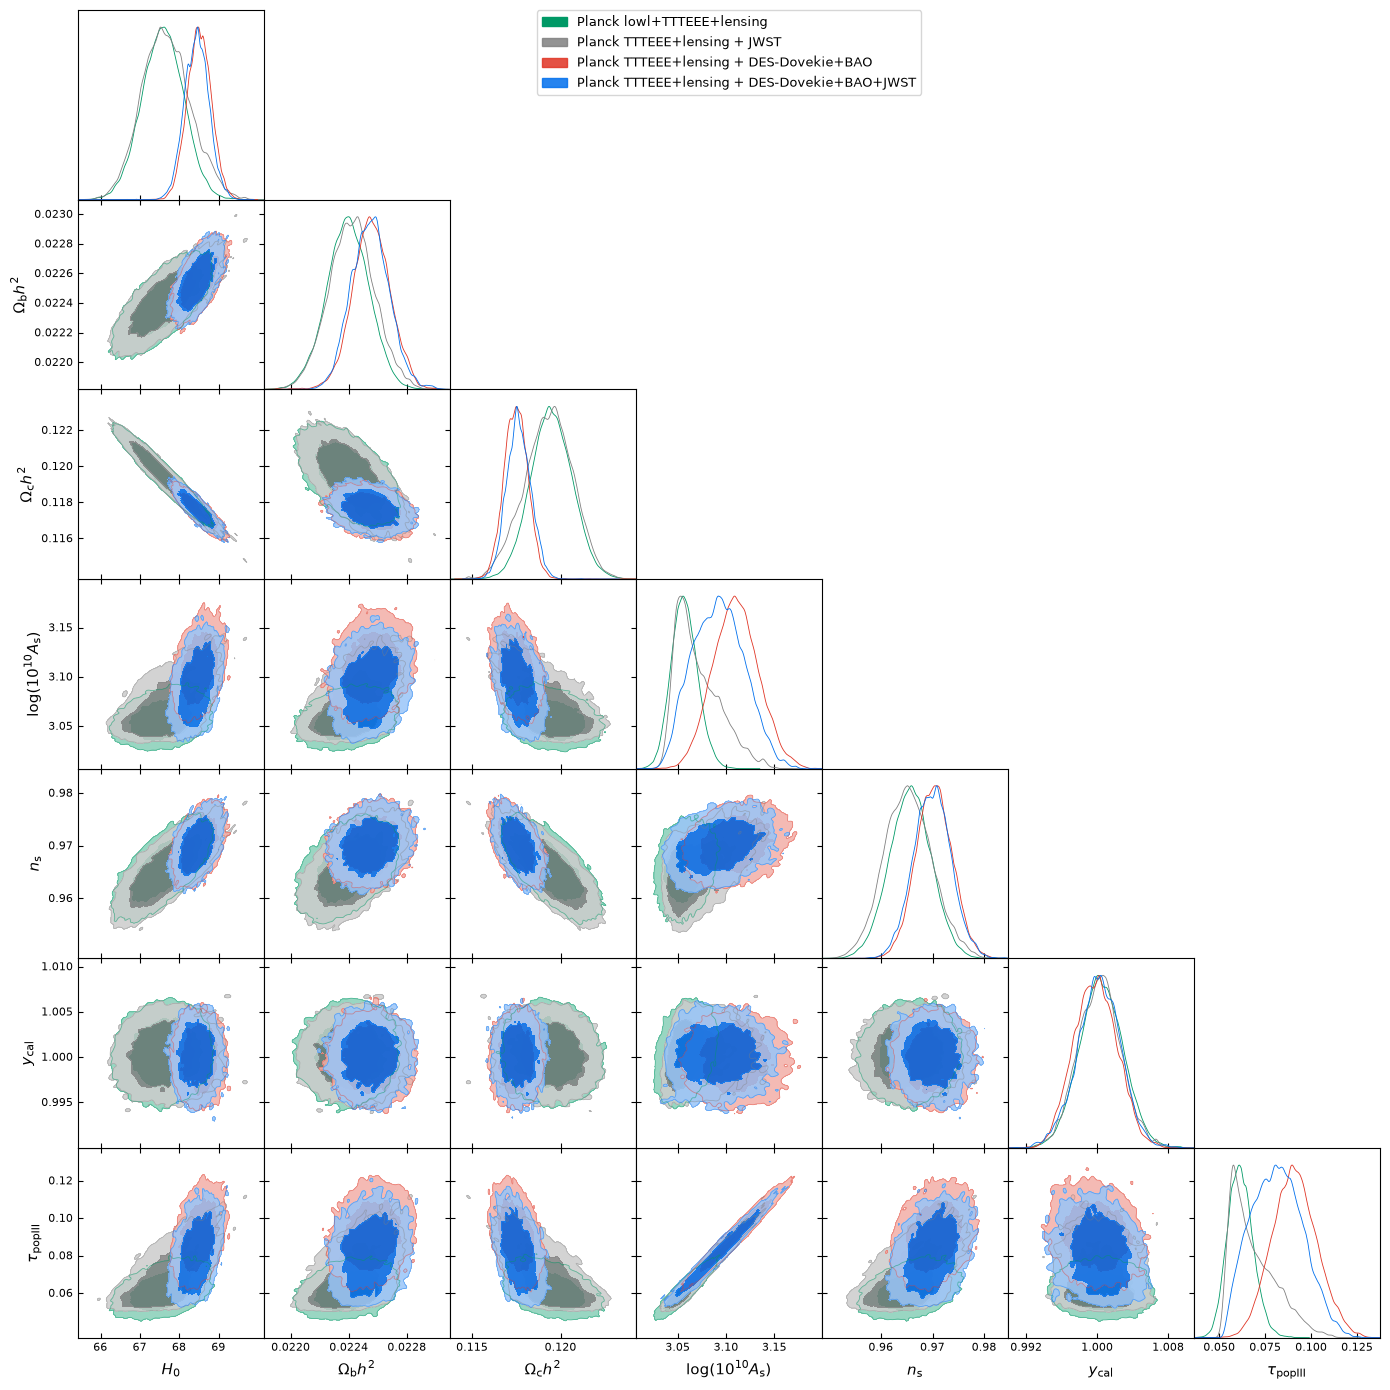

In [7]:
g = gdplot.get_subplot_plotter()

for s in samples.values():
    s.updateSettings({'smooth_scale_2D': 0.1, 'smooth_scale_1D': 0.1})

select_sims = slice(0, 4)

g.triangle_plot(
    [
        samples["lcdm_planck"],
        samples["lcdm_planck_jwst"],
        samples["lcdm_planck_desi_des"],
        samples["lcdm_planck_desi_des_jwst"]
    ][select_sims],
    # [samples["lcdm_planck_jwst"]],
    # reio_params,
    cosmo_params,
    filled=True,
    legend_labels=[
        "Planck lowl+TTTEEE+lensing",
        "Planck TTTEEE+lensing + JWST",
        "Planck TTTEEE+lensing + DES-Dovekie+BAO",
        "Planck TTTEEE+lensing + DES-Dovekie+BAO+JWST"
        ][select_sims],
    # title_limit=2,
)
plt.show()


In [26]:
def print_bounds_all(samples_dict, params, limit=1):
    """
        samples_dict:   {model name: getdist samples}
        params:         What parameters to print
        limit:          n-sigma bound, by default 1-sigma bound
    """

    stats = {run: s.getMargeStats() for run, s in samples_dict.items()}
    w = max(map(len, stats))
    for par in params:
        print(f"\n{par}")
        print(f"  {'':<{w}}{'mean':>12}{'lower':>12}{'upper':>12}")
        for run, m in stats.items():
            p = m.parWithName(par)
            if p is None:
                continue
            lim = p.limits[limit - 1]
            print(f"  {run:<{w}}{p.mean:>12.5g}{lim.lower:>12.5g}{lim.upper:>12.5g}")

print_bounds_all(samples, s.getParamNames().list()[:12] + ["jwst_popIII_tau"])


reio_jwst_popIII_logMvcut
                                   mean       lower       upper
  lcdm_planck                    7.4604       7.321           8
  lcdm_planck_jwst               6.6725      5.9081       7.514
  lcdm_planck_desi_des           7.3162      7.1753           8
  lcdm_planck_desi_des_jwst      6.1088      5.4299      6.5924

reio_jwst_popIII_fesc
                                   mean       lower       upper
  lcdm_planck                   0.09008        0.05    0.092972
  lcdm_planck_jwst             0.081457        0.05    0.083958
  lcdm_planck_desi_des          0.16554        0.05     0.18852
  lcdm_planck_desi_des_jwst    0.081103        0.05     0.08592

reio_jwst_popIII_a
                                   mean       lower       upper
  lcdm_planck                   0.15586     0.14843     0.16329
  lcdm_planck_jwst              0.15747     0.15018     0.16462
  lcdm_planck_desi_des          0.15294     0.14509     0.16076
  lcdm_planck_desi_des_jwst     0.